# Segmentación K-Means: Clusters de Producto-Región para Vanish

**Categoría de mercado:** Productos de limpieza para el hogar (canal autoservicio, México)

**Rol:** Modelado, diseño visual y análisis end-to-end (individual)

**Stack:** Python · pandas · NumPy · scikit-learn · Matplotlib · Seaborn

### Contexto

Este proyecto continúa el [pipeline ETL](https://github.com/ReginaPema/etl-sales-data-cleaning) y el [EDA](https://github.com/ReginaPema/eda-retail-sales-analysis) de consolidación y exploración de datos de ventas retail. Aquí se aplica clustering no supervisado (K-Means) para identificar segmentos internos dentro del portafolio de **Vanish**, la segunda marca del mercado por ventas, con el objetivo de entender qué combinaciones de producto y región comparten un mismo perfil de desempeño y qué implicaciones tiene eso para la estrategia comercial.

### Objetivo

1. Construir una tabla de agregación por combinación producto-región para Vanish.
2. Determinar el número óptimo de clusters mediante el método del codo y tres métricas de validación.
3. Perfilar y nombrar los clusters resultantes según su comportamiento de venta, precio y rotación.
4. Visualizar los clusters y su composición por segmento y región.
5. Comparar cada cluster contra el mercado total para entender la posición competitiva de Vanish.

### Nota metodológica

El análisis trabaja únicamente sobre las filas de región = Área Regional, excluyendo el total nacional (que es la suma agregada de las seis áreas, no una observación de venta independiente). Esto es crítico ya que, si el total nacional se incluyera como si fuera una séptima región, sus valores (que son sumas, no ventas individuales) se verían artificialmente enormes frente a cualquier área real, y el modelo de clustering terminaría agrupando por ese artefacto en lugar de por patrones de negocio genuinos.

**Sistema de diseño visual:** Este notebook reutiliza la misma paleta y estilo visual del proyecto de EDA, para que las piezas del portafolio se lean como parte de un mismo producto analítico.

### Resultado

Cinco clusters con perfiles claramente diferenciados, desde un núcleo de alto valor que concentra casi la mitad de los ingresos de la marca, hasta un grupo de presencia marginal candidato a revisión, que ofrecen una base concreta para priorizar decisiones de portafolio, precio y distribución.

---

## 1. Carga de datos y base de trabajo

Se carga el dataset consolidado y se filtra a las filas de área regional.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import warnings
warnings.filterwarnings("ignore")

df_completo = pd.read_parquet("df_consolidado_final.parquet")
df = df_completo[df_completo["region_type"] == "Área Regional"].copy()

print(f"Filas totales en el dataset: {len(df_completo):,}")
print(f"Filas de área regional (base de este análisis): {len(df):,}")
print(f"Ventas totales (áreas regionales): ${df['total_value_sales'].sum():,.2f}")

Filas totales en el dataset: 122,002
Filas de área regional (base de este análisis): 101,012
Ventas totales (áreas regionales): $5,521,430.57


### Sistema de diseño: paleta y estilo

Se reutiliza la misma paleta y el mismo estilo visual del proyecto de EDA, para que las tres piezas del portafolio se lean como parte de un mismo producto analítico.

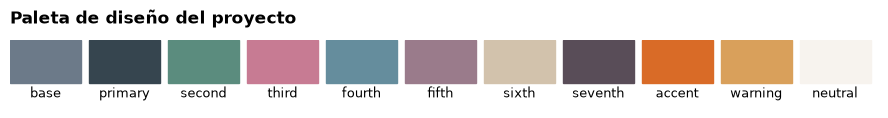

In [27]:
PALETTE = {
    "base":     "#6C7A89",  # gris azulado
    "primary":  "#36454F",  # azul charcoal
    "second":   "#5B8C7E",  # verde
    "third":    "#C77B93",  # rosa
    "fourth":   "#658D9D",  # muted blue
    "fifth":    "#9A7B8B",  # muted pink
    "sixth":    "#D2C2AC",  # muted beige
    "seventh":  "#594D58",  # graphite red
    "accent":   "#D96B27",  # coral
    "warning":  "#D9A05B",  # mostaza
    "neutral":  "#F7F3EE",  # beige claro
}

# Lista ordenada para gráficas categóricas
QUALITATIVE = [PALETTE["primary"], PALETTE["fifth"], PALETTE["second"],
               PALETTE["base"], PALETTE["fourth"], PALETTE["sixth"], PALETTE["warning"]]

# Colores fijos por segmento
SEGMENT_COLORS = dict(zip(
    df.groupby('segment', observed=True)['total_value_sales'].sum().sort_values(ascending=False).index,
    QUALITATIVE
))

# Colores fijos por región
REGION_COLORS = dict(zip(sorted(df['region_short'].unique()), QUALITATIVE))

# Mapas de color continuos
CMAP_DIVERGING = LinearSegmentedColormap.from_list("diverging_custom", [PALETTE["third"], PALETTE["neutral"], PALETTE["second"]])
CMAP_SEQUENTIAL = LinearSegmentedColormap.from_list("sequential_custom", [PALETTE["neutral"], PALETTE["seventh"]])

def aplicar_estilo():
    """Aplica el estilo visual consistente a toda gráfica de matplotlib/seaborn del notebook"""
    plt.rcParams.update({
        'figure.facecolor': 'white', 'axes.facecolor': 'white',
        'axes.spines.top': False, 'axes.spines.right': False,
        'axes.edgecolor': '#888888', 'axes.linewidth': 0.8,
        'axes.grid': True, 'grid.color': '#D9D9D9', 'grid.linewidth': 0.6, 'grid.alpha': 0.6,
        'axes.axisbelow': True,
        'font.family': 'DejaVu Sans', 'font.size': 10.5,
        'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
        'axes.labelsize': 10, 'axes.labelweight': 'medium',
        'legend.frameon': False, 'legend.fontsize': 9.5,
        'xtick.color': '#333333', 'ytick.color': '#333333',
        'figure.titlesize': 15, 'figure.titleweight': 'bold',
        'figure.figsize': (12, 6),
    })

aplicar_estilo()

fig, ax = plt.subplots(figsize=(9, 1.3))
for i, (nombre, color) in enumerate(PALETTE.items()):
    ax.add_patch(plt.Rectangle((i, 0), 0.9, 1, color=color))
    ax.text(i + 0.45, -0.35, nombre, ha='center', fontsize=9)
ax.set_xlim(0, len(PALETTE)); ax.set_ylim(-0.6, 1)
ax.axis('off')
plt.title('Paleta de diseño del proyecto', loc='left', fontsize=12)
plt.tight_layout()
plt.savefig("00_paleta_diseno.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Seleccionar las características para el clustering

## 2.1 Filtrar registros de la marca Vanish

El análisis se centra en **Vanish** para identificar sus segmentos internos y comparar su desempeño relativo frente al total del portafolio.

In [28]:
df_vanish = df[df['brand'].str.upper() == 'VANISH'].copy()

print(f"Registros de Vanish: {len(df_vanish):,} de {len(df):,} totales ({len(df_vanish)/len(df)*100:.1f}%)")
print(f"Ventas de Vanish: ${df_vanish['total_value_sales'].sum():,.2f}")
print(f"Participación en ventas totales: {df_vanish['total_value_sales'].sum()/df['total_value_sales'].sum()*100:.1f}%")
print(f"\nSegmentos en Vanish: {df_vanish['segment'].unique().tolist()}")
print(f"Formatos en Vanish: {df_vanish['format'].unique().tolist()}")
print(f"Regiones en Vanish: {sorted(df_vanish['region_short'].unique().tolist())}")

Registros de Vanish: 23,626 de 101,012 totales (23.4%)
Ventas de Vanish: $1,084,144.86
Participación en ventas totales: 19.6%

Segmentos en Vanish: ['Powder', 'Pretreat', 'Bar', 'Liquid & Gel']
Formatos en Vanish: ['Polvo', 'Liquido', 'Barra', 'Gel']
Regiones en Vanish: ['Area 1', 'Area 2', 'Area 3', 'Area 4', 'Area 5', 'Area 6']


## 2.2 Ingeniería de características

Se construye una tabla de agregación por combinación producto-región (item_code + region_short), condensando los registros semanales de Vanish en un registro único por cada par producto-región. Las características elegidas capturan cuatro dimensiones complementarias:

| Dimensión | Variables |
|---|---|
| Valor económico | sales_total, sales_mean, price_mean |
| Volumen / rotación | units_total, units_mean |
| Comportamiento | var_pct_mean, high_value_ratio, high_turnover_ratio |
| Presencia temporal | n_weeks |
| Características | segment, format |

Dos columnas del dataset original se excluyen:

- `above_avg`: como ya se documentó en el EDA, es una variable constante (siempre 0) dentro de las filas de área regional, porque el promedio histórico contra el que se compara (`total_unit_avg_weekly_sales`) está calibrado a una escala más amplia que la de una sola región. No aporta varianza.
- `total_unit_avg_weekly_sales`: es en sí mismo un promedio móvil calculado por la fuente de datos, no un valor por semana. Tomar su media aquí sería promediar un promedio ya suavizado. En su lugar, la rotación se mide con `units_mean` (el promedio real de unidades vendidas por semana, calculado directo de `total_unit_sales`), que mide lo mismo sin ese problema.

In [29]:
agg_dict = {
    'total_value_sales'          : ['sum', 'mean'],
    'total_unit_sales'           : ['sum', 'mean'],
    'avg_weekly_price'           : 'mean',
    'var_pct'                    : 'mean',
    'high_value'                 : 'mean',
    'high_turnover'              : 'mean',
    'segment'                    : 'first',
    'format'                     : 'first',
    'item_code'                  : 'count'
}

df_agg = df_vanish.groupby(['item_code', 'region_short']).agg(agg_dict)
df_agg.columns = [
    'sales_total', 'sales_mean', 'units_total', 'units_mean', 'price_mean',
    'var_pct_mean', 'high_value_ratio', 'high_turnover_ratio', 'segment', 'format', 'n_weeks'
]
df_agg = df_agg.reset_index().rename(columns={'region_short': 'region'})

print(f"Registros en la tabla de agregación: {len(df_agg):,}")
print(f"\nDistribución por segmento:")
for seg, cnt in df_agg['segment'].value_counts().items():
    print(f"  {seg:<13} {cnt:>4} ({cnt/len(df_agg)*100:.1f}%)")
print(f"\nDistribución por región:")
for reg, cnt in df_agg['region'].value_counts().items():
    print(f"  {reg:<8} {cnt:>4} ({cnt/len(df_agg)*100:.1f}%)")

Registros en la tabla de agregación: 402

Distribución por segmento:
  Liquid & Gel   181 (45.0%)
  Powder         167 (41.5%)
  Bar             42 (10.4%)
  Pretreat        12 (3.0%)

Distribución por región:
  Area 2     71 (17.7%)
  Area 1     69 (17.2%)
  Area 6     69 (17.2%)
  Area 4     65 (16.2%)
  Area 3     64 (15.9%)
  Area 5     64 (15.9%)


# 3. Estandarizar las características

De las 11 columnas numéricas y categóricas construidas en la tabla de agregación, el modelo usa 8 como variables de clustering. Quedan fuera:

- `segment`, `format`: son categóricas, K-Means necesita distancias numéricas. Se conservan en `df_agg` para perfilar los clusters después, no para calcular distancias.
- `sales_mean`: es casi redundante con `sales_total` combinada con `n_weeks` (que ya está en el modelo). Dividir el total entre las semanas presentes aproxima el promedio, así que incluir ambas versiones metería colinealidad sin aportar información nueva. 
- `units_mean` sí se conserva como feature porque es la métrica de rotación elegida.

K-Means se basa en distancias, así que las variables deben estar en la misma escala antes de entrenar el modelo. Se usa StandardScaler (media 0, desviación estándar 1) sobre las 8 características numéricas resultantes.

In [30]:
features = [
    'sales_total', 'price_mean', 'units_total', 'units_mean', 'var_pct_mean',
    'high_value_ratio', 'high_turnover_ratio', 'n_weeks'
]

X = df_agg[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Características utilizadas: {len(features)}")
print(f"Forma de la matriz escalada: {X_scaled.shape}")
print(f"\nVerificación tras StandardScaler:")
X_check = pd.DataFrame(X_scaled, columns=features)
print(f"  Media promedio (aprox 0) → {X_check.mean().mean():.6f}")
print(f"  Std promedio (aprox 1)   → {X_check.std().mean():.6f}")

Características utilizadas: 8
Forma de la matriz escalada: (402, 8)

Verificación tras StandardScaler:
  Media promedio (aprox 0) → 0.000000
  Std promedio (aprox 1)   → 1.001246


# 4. Aplicar el algoritmo K-Means

## 4.1 Método del codo y métricas de validación

Se evalúan valores de k entre 2 y 10 con cuatro criterios: inercia (método del codo), Silhouette Score, Davies-Bouldin Index y Calinski-Harabasz Index.

In [31]:
k_range = range(2, 11)
inertia, silhouette, davies, calinski = [], [], [], []

print(f"{'k':>3} {'Inercia':>12} {'Silhouette':>12} {'Davies-Bouldin':>15} {'Calinski-Harabasz':>18}")
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    silhouette.append(sil); davies.append(db); calinski.append(ch)
    print(f"{k:>3} {km.inertia_:>12,.2f} {sil:>12.4f} {db:>15.4f} {ch:>18.2f}")

  k      Inercia   Silhouette  Davies-Bouldin  Calinski-Harabasz
  2     2,079.34       0.4100          1.1340             218.66
  3     1,440.72       0.3732          1.0271             245.83
  4     1,108.77       0.3831          0.9903             252.13
  5       885.59       0.4122          0.9108             261.18
  6       757.92       0.3972          0.8982             256.86
  7       652.32       0.3965          0.8498             258.73
  8       572.24       0.3916          0.8756             260.04
  9       505.01       0.4011          0.9162             263.71
 10       440.89       0.4091          0.8788             274.16


### Interpretación

Cada métrica evalúa la calidad de los clusters desde un ángulo distinto:

| Métrica | ¿Qué mide? | ¿Mejor valor? | ¿Se puede leer directo de la tabla? |
|---|---|---|---|
| **Inercia** | Qué tan compactos son los clusters (suma de distancias al centroide) | Más bajo es mejor, pero *siempre* baja al aumentar k | No → su mínimo real es en k = número de filas (cada punto su propio cluster), así que hay que buscar el "codo": el punto donde deja de bajar tan rápido, no el valor más bajo |
| **Silhouette Score** | Qué tan bien separado está cada punto de otros clusters frente al propio | Más alto es mejor (rango -1 a 1; cerca de 1 = bien separado, cerca de 0 = clusters se traslapan) | Sí → el máximo de la columna es directamente el mejor k según esta métrica |
| **Davies-Bouldin** | Qué tan parecidos son los clusters entre sí (similitud promedio con su vecino más cercano) | Más bajo es mejor (0 = separación perfecta, sin techo definido) | Sí → el mínimo de la columna es directamente el mejor k según esta métrica |
| **Calinski-Harabasz** | Relación entre la dispersión *entre* clusters y la dispersión *dentro* de cada cluster | Más alto es mejor (sin techo definido) | Sí, pero con matiz → puede seguir subiendo con k sin un pico claro cuando los datos no tienen una separación natural muy marcada, así que conviene leerla junto con las otras tres, no sola |

**En resumen:** Silhouette y Davies-Bouldin sí se pueden leer directo del número (se busca el máximo o el mínimo de la columna). Inercia necesita la gráfica, porque su "mejor" valor por definición siempre está en el k más alto que se pruebe, así que el número solo no dice nada, se necesita ver dónde se dobla la curva. Calinski-Harabasz es intermedio: técnicamente se puede leer el máximo directo, pero conviene contrastarlo con las demás porque no siempre marca un pico igual de claro.

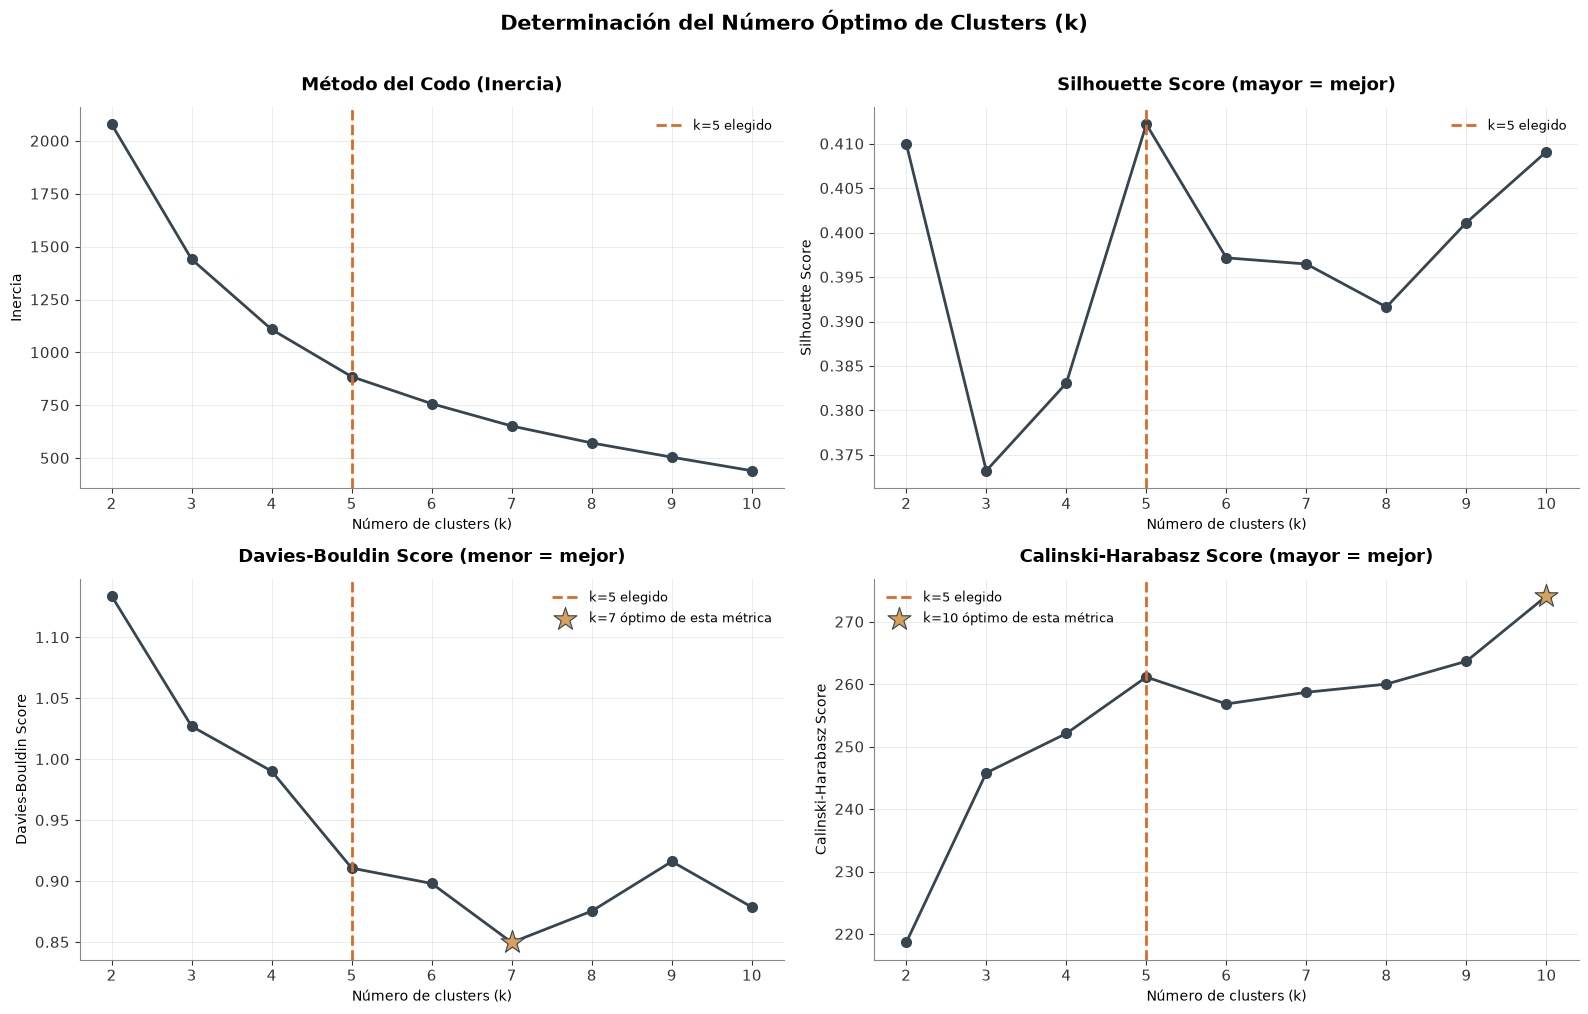

k=5  →  Silhouette 0.4122 | Davies-Bouldin 0.9108 | Calinski-Harabasz 261.18


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Determinación del Número Óptimo de Clusters (k)', y=1.01)

ks = list(k_range)

def marcar_optimo(ax, valores, mejor_es_max, k_elegido=5):
    """Marca con una estrella el k con el mejor valor de esta métrica, solo si es distinto de k_elegido."""
    idx_opt = valores.index(max(valores) if mejor_es_max else min(valores))
    k_opt = ks[idx_opt]
    if k_opt != k_elegido:
        ax.scatter([k_opt], [valores[idx_opt]], marker='*', s=300, color=PALETTE['warning'],
                   edgecolors=PALETTE['primary'], linewidth=0.8, zorder=5, label=f'k={k_opt} óptimo de esta métrica')

axes[0, 0].plot(ks, inertia, marker='o', linewidth=2, markersize=7, color=PALETTE['primary'])
axes[0, 0].axvline(x=5, color=PALETTE['accent'], linestyle='--', linewidth=2, label='k=5 elegido')
axes[0, 0].set_title('Método del Codo (Inercia)')
axes[0, 0].set_xlabel('Número de clusters (k)'); axes[0, 0].set_ylabel('Inercia')
axes[0, 0].legend()

axes[0, 1].plot(ks, silhouette, marker='o', linewidth=2, markersize=7, color=PALETTE['primary'])
axes[0, 1].axvline(x=5, color=PALETTE['accent'], linestyle='--', linewidth=2, label='k=5 elegido')
marcar_optimo(axes[0, 1], silhouette, mejor_es_max=True)
axes[0, 1].set_title('Silhouette Score (mayor = mejor)')
axes[0, 1].set_xlabel('Número de clusters (k)'); axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].legend()

axes[1, 0].plot(ks, davies, marker='o', linewidth=2, markersize=7, color=PALETTE['primary'])
axes[1, 0].axvline(x=5, color=PALETTE['accent'], linestyle='--', linewidth=2, label='k=5 elegido')
marcar_optimo(axes[1, 0], davies, mejor_es_max=False)
axes[1, 0].set_title('Davies-Bouldin Score (menor = mejor)')
axes[1, 0].set_xlabel('Número de clusters (k)'); axes[1, 0].set_ylabel('Davies-Bouldin Score')
axes[1, 0].legend()

axes[1, 1].plot(ks, calinski, marker='o', linewidth=2, markersize=7, color=PALETTE['primary'])
axes[1, 1].axvline(x=5, color=PALETTE['accent'], linestyle='--', linewidth=2, label='k=5 elegido')
marcar_optimo(axes[1, 1], calinski, mejor_es_max=True)
axes[1, 1].set_title('Calinski-Harabasz Score (mayor = mejor)')
axes[1, 1].set_xlabel('Número de clusters (k)'); axes[1, 1].set_ylabel('Calinski-Harabasz Score')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('11_metodo_codo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"k=5  →  Silhouette {silhouette[3]:.4f} | Davies-Bouldin {davies[3]:.4f} | Calinski-Harabasz {calinski[3]:.2f}")

### Hallazgos

- La curva de inercia no tiene un único "mejor" punto matemático (siempre baja al aumentar k), pero sí muestra un codo visual razonable alrededor de k=4-5: el ritmo de descenso se hace notablemente más lento a partir de ahí.
- Silhouette alcanza su valor más alto exactamente en k=5 (0.412), el mejor de los 9 valores de k evaluados, sin ambigüedad, es la señal más limpia de las cuatro.
- Calinski-Harabasz forma un pico local genuino en k=5 (261.18), por encima de sus vecinos inmediatos k=4 (252.13) y k=6 (256.86), antes de volver a subir hacia k=9-10. Un pico local seguido de una caída es una señal reconocida de estructura real, distinta de una curva que solo sigue creciendo sin parar, aunque el máximo global de esta métrica esté en k=10, el comportamiento en k=5 sí respalda la elección.
- Davies-Bouldin es la única métrica sin un mínimo o pico local en k=5: es un punto más dentro de una curva que sigue bajando hasta su mínimo real en k=7 (0.8498). Es la métrica que, si se considerara sola, cambiaría el número de clusters.

### Interpretación

Tres de las cuatro señales respaldan a k=5 de forma genuina, el codo visual de la inercia, el máximo limpio de Silhouette, y el pico local de Calinski-Harabasz; mientras que Davies-Bouldin es la disidencia honesta, con una preferencia por k=7. Junto con que 5 clusters siguen siendo un número manejable para comunicar y accionar en negocio (7, 9 o 10 empiezan a fragmentar los grupos en segmentos más difíciles de interpretar), se elige k=5 como número óptimo de clusters.

## 4.2 Modelo K-Means final con k = 5

In [33]:
k_optimo = 5

kmeans_final = KMeans(
    n_clusters=k_optimo,
    init='k-means++',
    n_init=50,
    max_iter=500,
    random_state=42
)

df_agg['cluster'] = kmeans_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df_agg['cluster'])
db_final = davies_bouldin_score(X_scaled, df_agg['cluster'])
ch_final = calinski_harabasz_score(X_scaled, df_agg['cluster'])

print(f"k elegido               → {k_optimo}")
print(f"Inercia final           → {kmeans_final.inertia_:,.2f}")
print(f"Silhouette Score        → {sil_final:.4f} (objetivo > 0.25)")
print(f"Davies-Bouldin Score    → {db_final:.4f} (objetivo < 1.5)")
print(f"Calinski-Harabasz Score → {ch_final:.2f}")

print(f"\nTamaño de los clusters:")
for c, cnt in df_agg['cluster'].value_counts().sort_index().items():
    print(f"  Cluster {c}: {cnt:>3} registros ({cnt/len(df_agg)*100:.1f}%)")

k elegido               → 5
Inercia final           → 885.58
Silhouette Score        → 0.4122 (objetivo > 0.25)
Davies-Bouldin Score    → 0.9106 (objetivo < 1.5)
Calinski-Harabasz Score → 261.18

Tamaño de los clusters:
  Cluster 0: 129 registros (32.1%)
  Cluster 1:  54 registros (13.4%)
  Cluster 2: 140 registros (34.8%)
  Cluster 3:  57 registros (14.2%)
  Cluster 4:  22 registros (5.5%)


# 5. Evaluar los resultados del clustering

## 5.1 Perfiles de los clusters

In [34]:
centroides_originales = scaler.inverse_transform(kmeans_final.cluster_centers_)
df_centroides = pd.DataFrame(centroides_originales, columns=features)
df_centroides.index.name = 'cluster'

print("Valores promedio de cada cluster, en escala original:")
print(df_centroides.round(3).to_string())

metricas_cluster = df_agg.groupby('cluster').agg(
    n_registros=('item_code', 'count'), productos_unicos=('item_code', 'nunique'), regiones_unicas=('region', 'nunique'),
    ventas_totales=('sales_total', 'sum'), venta_media=('sales_total', 'mean'),
    precio_medio=('price_mean', 'mean'), unidades_totales=('units_total', 'sum'),
    rotacion_sem_media=('units_mean', 'mean'), variacion_mercado=('var_pct_mean', 'mean'),
    ratio_alto_valor=('high_value_ratio', 'mean'), ratio_alta_rotacion=('high_turnover_ratio', 'mean'),
    semanas_promedio=('n_weeks', 'mean')
).round(3)

print("\n\nResumen estadístico por cluster (ordenado por ventas totales):")
print(metricas_cluster.sort_values('ventas_totales', ascending=False).to_string())

Valores promedio de cada cluster, en escala original:
         sales_total  price_mean  units_total  units_mean  var_pct_mean  high_value_ratio  high_turnover_ratio  n_weeks
cluster                                                                                                                
0             13.503      30.176        0.595       0.012       -99.613             0.262                0.122   23.527
1           2402.481      21.369      118.807       1.532       -85.935             0.096                0.965   75.556
2           1646.022     126.837       12.712       0.162       -94.038             0.991                0.183   72.964
3           8823.732      95.637      110.902       1.392       -72.452             0.980                0.782   79.579
4           9966.965      17.177      594.232       7.428       -66.982             0.000                1.000   80.000


Resumen estadístico por cluster (ordenado por ventas totales):
         n_registros  productos_unicos  r

**Nota:** variacion_mercado es negativa en los cinco clusters. Esto es consistente con lo que ya se documentó en el EDA: la mediana de var_pct en todo el dataset es -91.8%, porque el promedio histórico de referencia está calibrado a una escala más amplia que la venta semanal individual de cualquier producto-región. No debe leerse como que los cinco clusters "van mal"; es el patrón general de la variable en toda la base de datos. Lo relevante es la comparación entre clusters, no el signo absoluto.

## 5.2 Asignar nombres descriptivos a los clusters según sus perfiles

In [35]:
cluster_nombres = {
    3: 'Motor de Ingresos',
    2: 'Nicho Premium',
    4: 'Alta Rotación',
    1: 'Volumen Diversificado',
    0: 'Presencia Marginal',
}

cluster_colores = {
    0: PALETTE['primary'],
    1: PALETTE['sixth'],
    2: PALETTE['fifth'],
    3: PALETTE['fourth'],
    4: PALETTE['second'],
}

df_agg['cluster_nombre'] = df_agg['cluster'].map(cluster_nombres)
df_agg['cluster_color'] = df_agg['cluster'].map(cluster_colores)

print("Mapping de clusters:")
for c, nombre in cluster_nombres.items():
    print(f"\nCluster {c} → '{nombre}'")
    print(f"  Registros producto-región : {metricas_cluster.loc[c, 'n_registros']:,.0f}")
    print(f"  Ventas acumuladas         : ${metricas_cluster.loc[c, 'ventas_totales']:,.2f}")
    print(f"  Precio promedio           : ${metricas_cluster.loc[c, 'precio_medio']:,.2f}")
    print(f"  Rotación semanal promedio : {metricas_cluster.loc[c, 'rotacion_sem_media']:,.2f} uds/semana")
    print(f"  Semanas alto valor        : {metricas_cluster.loc[c, 'ratio_alto_valor']*100:.1f}%")
    print(f"  Semanas alta rotación     : {metricas_cluster.loc[c, 'ratio_alta_rotacion']*100:.1f}%")
    print(f"  Presencia temporal        : {metricas_cluster.loc[c, 'semanas_promedio']:.0f} semanas promedio")

Mapping de clusters:

Cluster 3 → 'Motor de Ingresos'
  Registros producto-región : 57
  Ventas acumuladas         : $502,952.71
  Precio promedio           : $95.64
  Rotación semanal promedio : 1.39 uds/semana
  Semanas alto valor        : 98.0%
  Semanas alta rotación     : 78.2%
  Presencia temporal        : 80 semanas promedio

Cluster 2 → 'Nicho Premium'
  Registros producto-región : 140
  Ventas acumuladas         : $230,443.09
  Precio promedio           : $126.84
  Rotación semanal promedio : 0.16 uds/semana
  Semanas alto valor        : 99.1%
  Semanas alta rotación     : 18.3%
  Presencia temporal        : 73 semanas promedio

Cluster 4 → 'Alta Rotación'
  Registros producto-región : 22
  Ventas acumuladas         : $219,273.24
  Precio promedio           : $17.18
  Rotación semanal promedio : 7.43 uds/semana
  Semanas alto valor        : 0.0%
  Semanas alta rotación     : 100.0%
  Presencia temporal        : 80 semanas promedio

Cluster 1 → 'Volumen Diversificado'
  Registr

### Interpretación de los cinco clusters

- Cluster 3, Motor de Ingresos (57 combinaciones, $503K, 46.4% de las ventas de Vanish): combina un precio alto ($95.64) con una rotación sólida (1.39 uds/semana en promedio real) y presencia casi constante (79.6 semanas). Es, con diferencia, el cluster de mayor contribución económica: casi la mitad del ingreso de la marca proviene de aquí.
- Cluster 2, Nicho Premium (140 combinaciones, $230K, 21.3%): el precio más alto de todo el portafolio ($126.84) y el mayor porcentaje de semanas de alto valor (99.1%), pero la rotación más baja de todos los clusters (0.16 uds/semana). Vende caro, casi no gira.
- Cluster 4, Alta Rotación (22 combinaciones, $219K, 20.2%): solo 5 productos únicos, pero con una rotación disparada (7.43 uds/semana, la más alta de todo el portafolio) al precio más bajo ($17.18) y 100% de sus semanas clasificadas como alta rotación. Un grupo pequeño y muy específico.
- Cluster 1, Volumen Diversificado (54 combinaciones, $130K, 12.0%): precio bajo ($21.37) y rotación alta (1.53 uds/semana) con presencia amplia, similar en espíritu al Cluster 4 pero menos extremo y con más productos involucrados (17 únicos).
- Cluster 0, Presencia Marginal (129 combinaciones, apenas $1.7K, 0.2%): el cluster más grande en número de combinaciones pero el más pequeño en ingresos, con la presencia temporal más baja (23.5 semanas, menos de un tercio de los demás clusters). Es la principal área de revisión del portafolio.

# 6. Visualizar los clusters

## 6.1 PCA 2D: dispersión de clusters en espacio reducido

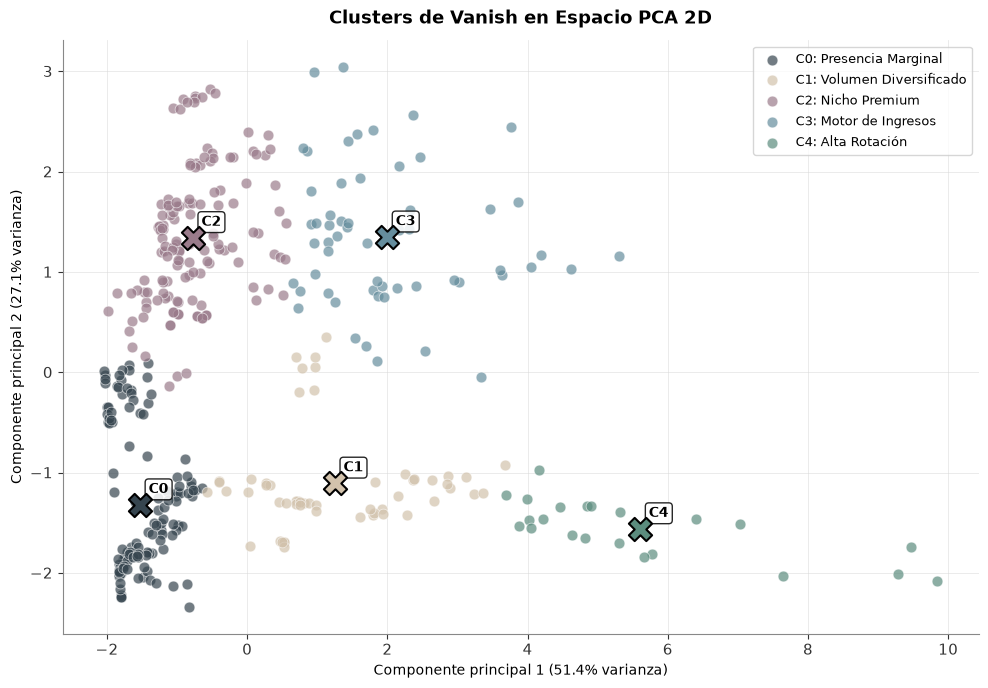

Varianza explicada: PC1 51.4% + PC2 27.1% = 78.4% del total


In [36]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
varianza_explicada = pca.explained_variance_ratio_

df_agg['pca1'] = X_pca[:, 0]
df_agg['pca2'] = X_pca[:, 1]
centroides_pca = pca.transform(kmeans_final.cluster_centers_)

fig, ax = plt.subplots(figsize=(10, 7))
for c in sorted(df_agg['cluster'].unique()):
    mask = df_agg['cluster'] == c
    ax.scatter(df_agg.loc[mask, 'pca1'], df_agg.loc[mask, 'pca2'], color=cluster_colores[c],
               label=f"C{c}: {cluster_nombres[c]}", alpha=0.70, s=60, edgecolors='white', linewidth=0.5)
for c in sorted(df_agg['cluster'].unique()):
    ax.scatter(centroides_pca[c, 0], centroides_pca[c, 1], color=cluster_colores[c], marker='X', s=280,
               edgecolors='black', linewidth=1.5, zorder=5)
    ax.text(centroides_pca[c, 0] + 0.12, centroides_pca[c, 1] + 0.12, f"C{c}", fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85))

ax.set_title('Clusters de Vanish en Espacio PCA 2D')
ax.set_xlabel(f'Componente principal 1 ({varianza_explicada[0]*100:.1f}% varianza)')
ax.set_ylabel(f'Componente principal 2 ({varianza_explicada[1]*100:.1f}% varianza)')
ax.legend(loc='best', frameon=True)
plt.tight_layout()
plt.savefig('12_scatter_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Varianza explicada: PC1 {varianza_explicada[0]*100:.1f}% + PC2 {varianza_explicada[1]*100:.1f}% = {varianza_explicada.sum()*100:.1f}% del total")

### Hallazgos

La proyección en 2D captura cerca de 78% de la varianza total de las 8 variables originales, así que parte de la separación real entre clusters se pierde en esta vista (K-Means fue entrenado sobre el espacio completo de 8 dimensiones, no sobre esta proyección). Aun así, se observa una separación razonable entre los cinco grupos, con Alta Rotación claramente aislado del resto por su perfil tan distintivo, y cierto solapamiento entre Motor de Ingresos y Volumen Diversificado, consistente con que ambos combinan precio moderado y rotación real en proporciones parecidas aunque no idénticas.

## 6.2 Ventas totales por cluster

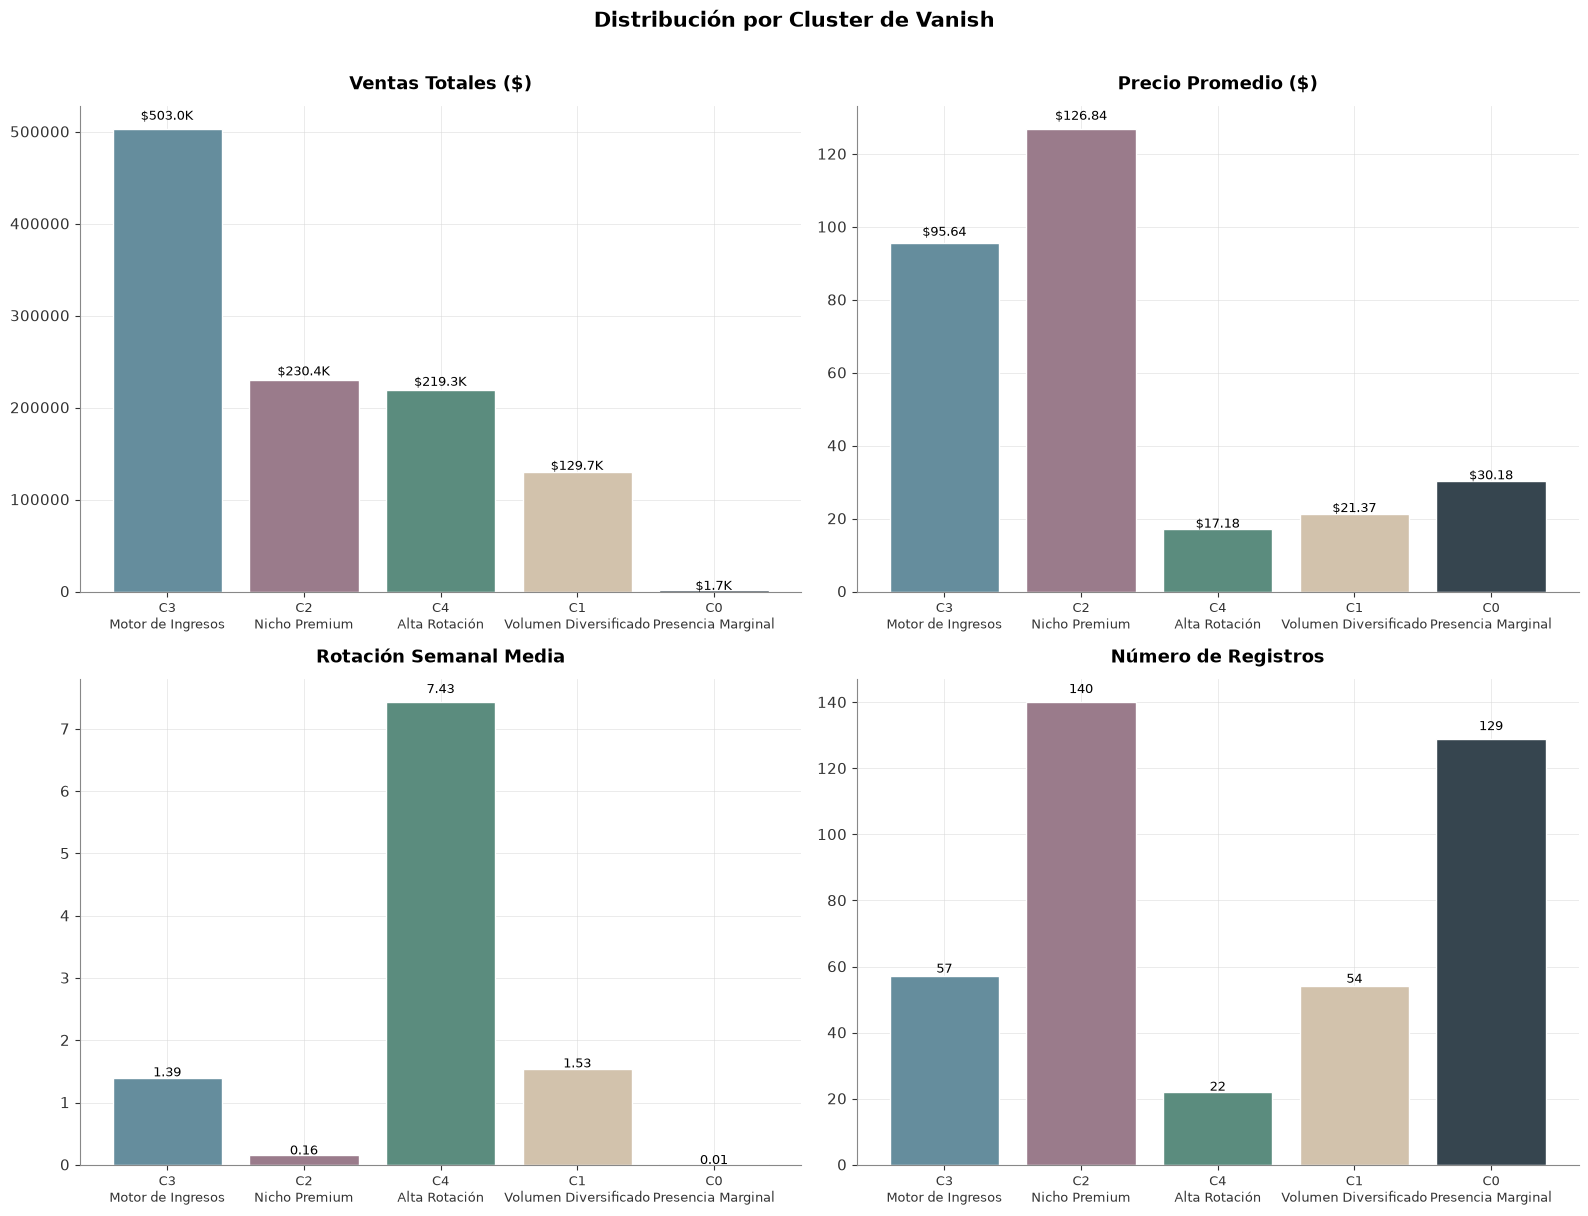

In [37]:
ventas_cluster = df_agg.groupby(['cluster', 'cluster_nombre']).agg(
    ventas_totales=('sales_total', 'sum'), n_registros=('item_code', 'count'),
    precio_medio=('price_mean', 'mean'), rotacion_sem_media=('units_mean', 'mean')
).reset_index().sort_values('ventas_totales', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribución por Cluster de Vanish', y=1.01)

etiquetas = [f"C{r['cluster']}\n{r['cluster_nombre']}" for _, r in ventas_cluster.iterrows()]
colores_c = [cluster_colores[r['cluster']] for _, r in ventas_cluster.iterrows()]

bars = axes[0,0].bar(etiquetas, ventas_cluster['ventas_totales'], color=colores_c, edgecolor='white')
axes[0,0].set_title('Ventas Totales ($)')
axes[0,0].tick_params(axis='x', labelsize=9)
for bar, v in zip(bars, ventas_cluster['ventas_totales']):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02, f'${v/1e3:.1f}K', ha='center', fontsize=9)

bars1 = axes[0,1].bar(etiquetas, ventas_cluster['precio_medio'], color=colores_c, edgecolor='white')
axes[0,1].set_title('Precio Promedio ($)')
axes[0,1].tick_params(axis='x', labelsize=9)
for bar, v in zip(bars1, ventas_cluster['precio_medio']):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02, f'${v:.2f}', ha='center', fontsize=9)

bars2 = axes[1,0].bar(etiquetas, ventas_cluster['rotacion_sem_media'], color=colores_c, edgecolor='white')
axes[1,0].set_title('Rotación Semanal Media')
axes[1,0].tick_params(axis='x', labelsize=9)
for bar, v in zip(bars2, ventas_cluster['rotacion_sem_media']):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02, f'{v:.2f}', ha='center', fontsize=9)

bars3 = axes[1,1].bar(etiquetas, ventas_cluster['n_registros'], color=colores_c, edgecolor='white')
axes[1,1].set_title('Número de Registros')
axes[1,1].tick_params(axis='x', labelsize=9)
for bar, v in zip(bars3, ventas_cluster['n_registros']):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('13_ventas_por_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3 Heatmap de perfiles de clusters

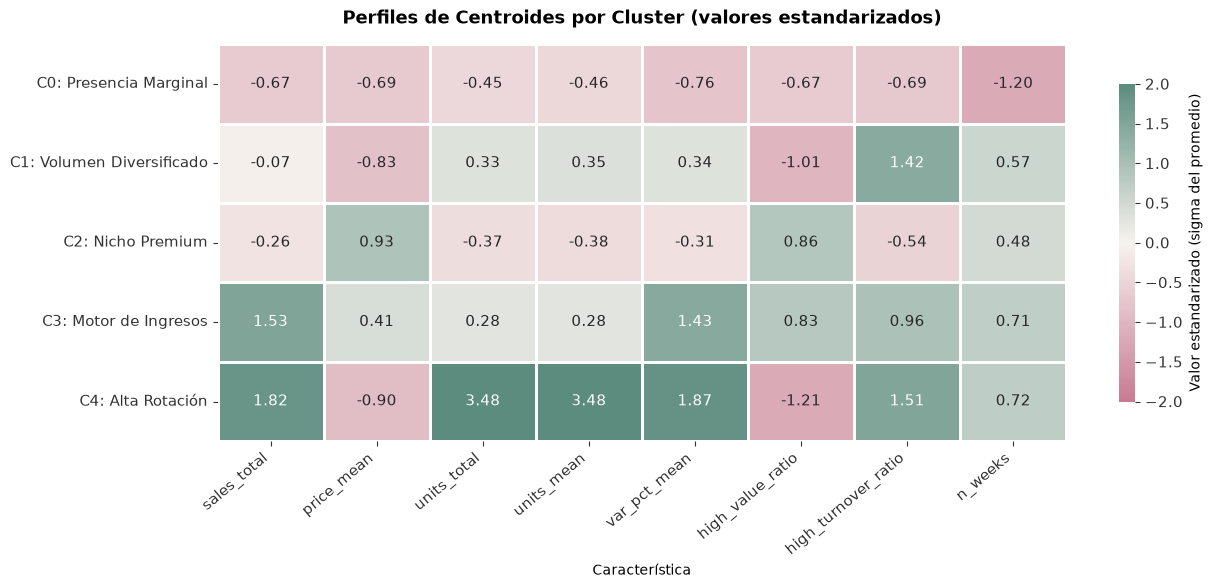

In [38]:
centroides_df = pd.DataFrame(kmeans_final.cluster_centers_, columns=features,
                             index=[f"C{c}: {cluster_nombres[c]}" for c in range(k_optimo)])

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(centroides_df, annot=True, fmt='.2f', cmap=CMAP_DIVERGING, center=0, vmin=-2, vmax=2,
            linewidths=1, linecolor='white', cbar_kws={'label': 'Valor estandarizado (sigma del promedio)', 'shrink': 0.8}, ax=ax)
ax.set_title('Perfiles de Centroides por Cluster (valores estandarizados)', pad=15)
ax.set_xlabel('Característica'); ax.set_ylabel('')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('14_heatmap_perfiles.png', dpi=150, bbox_inches='tight')
plt.show()

### Hallazgos

El heatmap confirma visualmente los perfiles descritos en la sección 5.2:

- **Motor de Ingresos** destaca en sales_total (1.53), aunque Alta Rotación lo supera en este valor estandarizado por combinación (1.82). Motor de Ingresos gana en dólares totales acumulados porque agrupa más combinaciones (57 vs. 22), no porque cada una individual sea más extrema; en units_total su valor es solo moderadamente positivo (0.28), por debajo incluso de Volumen Diversificado (0.33).
- **Nicho Premium** sobresale en price_mean (0.93) con valores negativos marcados en units_mean (-0.38) y high_turnover_ratio (-0.54): vende caro, casi no gira.
- **Alta Rotación** es, con diferencia, el más extremo en units_total y units_mean (3.48 en ambos) y en high_turnover_ratio (1.51), con price_mean fuertemente negativo (-0.90).
- **Volumen Diversificado** no tiene ningún valor tan extremo como los otros cuatro clusters, pero combina high_turnover_ratio alto (1.42) con high_value_ratio muy negativo (-1.01), esto es, la misma estrategia de precio bajo/rotación alta que Alta Rotación, en una versión más moderada y con base de productos más amplia.
- **Presencia Marginal** tiene la fila más uniformemente negativa, incluyendo n_weeks (-1.20). Su presencia temporal reducida es una característica definitoria del grupo.

## 6.4 Distribución por segmento y región dentro de cada cluster

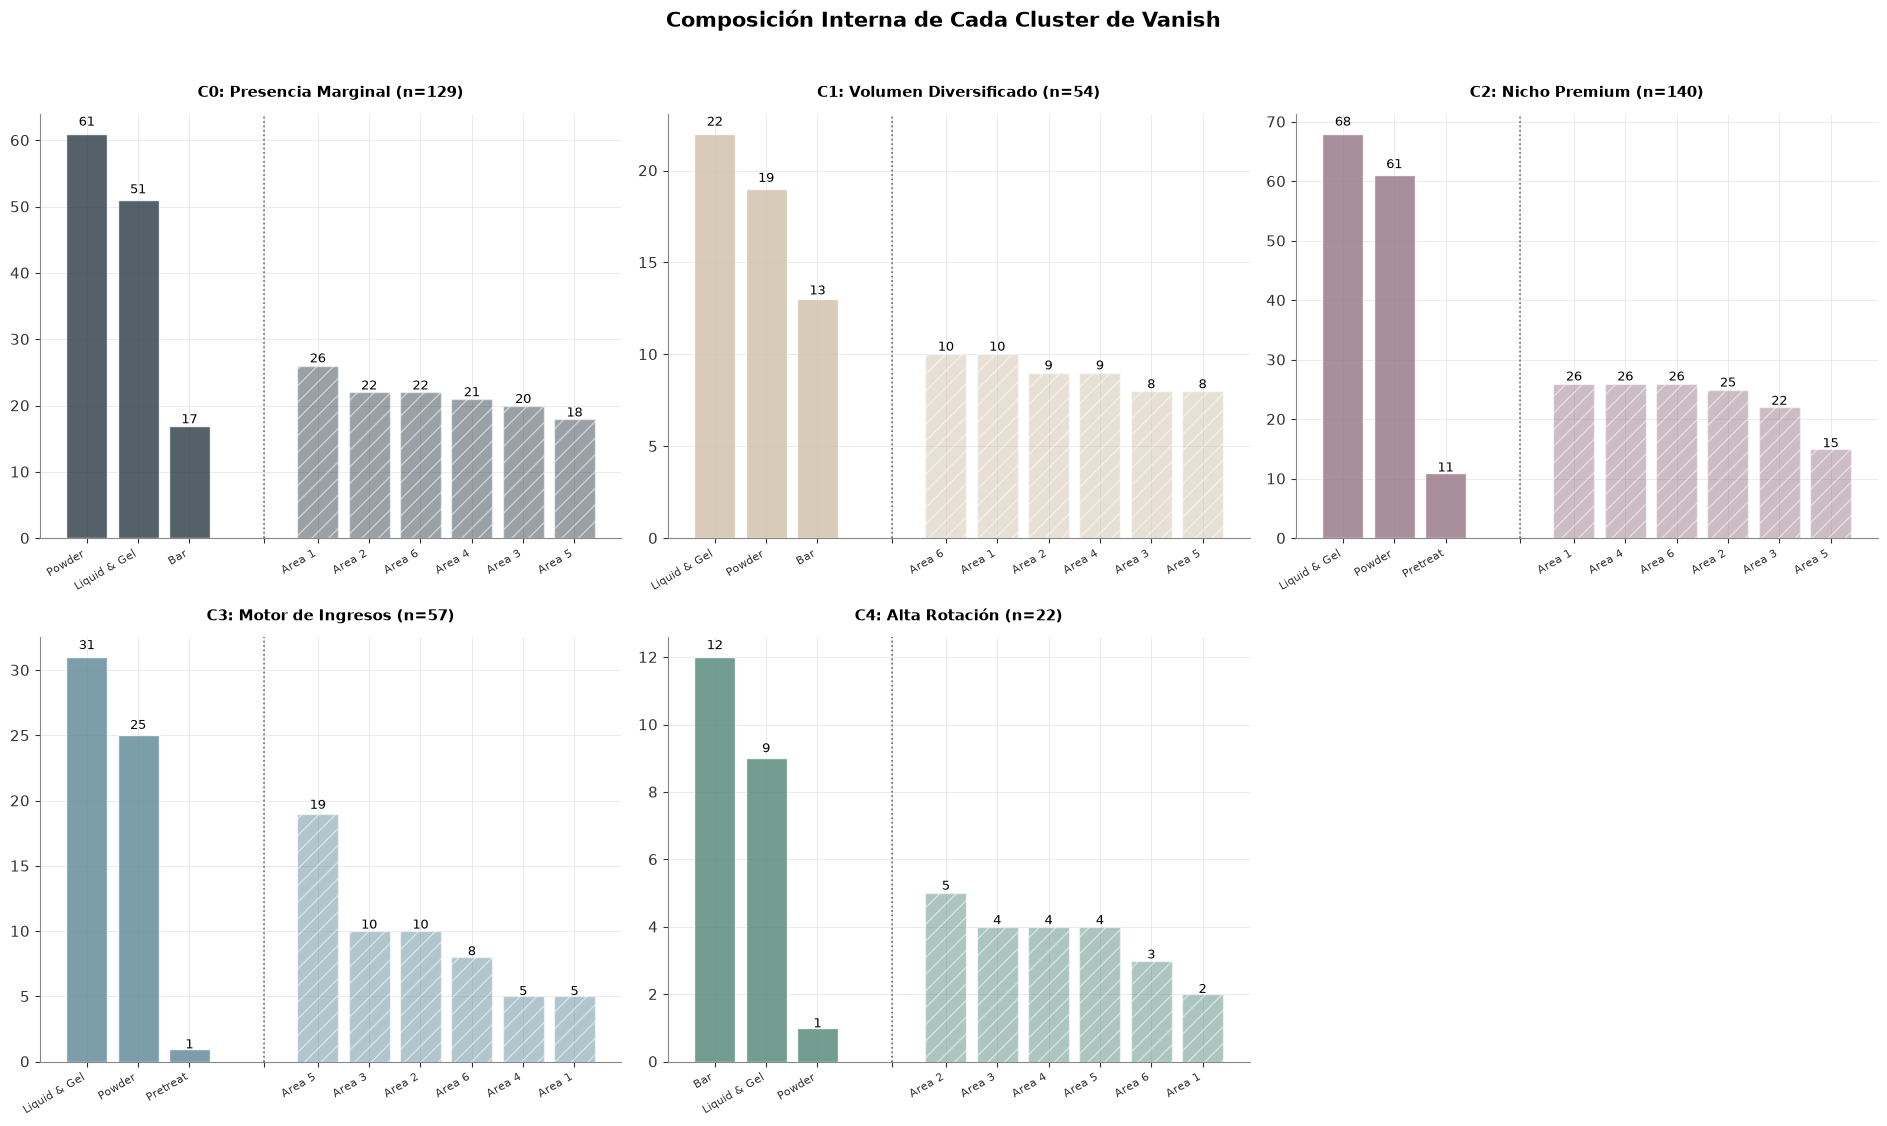

Composición por segmento:
segment                Bar  Liquid & Gel  Powder  Pretreat
cluster_nombre                                            
Alta Rotación           12             9       1         0
Motor de Ingresos        0            31      25         1
Nicho Premium            0            68      61        11
Presencia Marginal      17            51      61         0
Volumen Diversificado   13            22      19         0

Composición por región:
region                 Area 1  Area 2  Area 3  Area 4  Area 5  Area 6
cluster_nombre                                                       
Alta Rotación               2       5       4       4       4       3
Motor de Ingresos           5      10      10       5      19       8
Nicho Premium              26      25      22      26      15      26
Presencia Marginal         26      22      20      21      18      22
Volumen Diversificado      10       9       8       9       8      10


In [39]:
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
fig.suptitle('Composición Interna de Cada Cluster de Vanish', y=1.02)
axes_flat = axes.flatten()

for idx, c in enumerate(range(k_optimo)):
    ax = axes_flat[idx]
    df_c = df_agg[df_agg['cluster'] == c]
    seg_counts = df_c['segment'].value_counts()
    reg_counts = df_c['region'].value_counts()

    x_seg = np.arange(len(seg_counts))
    x_reg = np.arange(len(reg_counts)) + len(seg_counts) + 1.5

    bars1 = ax.bar(x_seg, seg_counts.values, color=cluster_colores[c], alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x_reg, reg_counts.values, color=cluster_colores[c], alpha=0.5, edgecolor='white', hatch='//')

    for bar, v in zip(bars1, seg_counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02, str(v), ha='center', fontsize=9)
    for bar, v in zip(bars2, reg_counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02, str(v), ha='center', fontsize=9)

    all_labels = list(seg_counts.index) + [''] + list(reg_counts.index)
    all_x = list(x_seg) + [len(seg_counts)+0.45] + list(x_reg)
    ax.set_xticks(all_x); ax.set_xticklabels(all_labels, fontsize=8, rotation=30, ha='right')
    ax.set_title(f"C{c}: {cluster_nombres[c]} (n={len(df_c)})", fontsize=11)
    ax.axvline(x=len(seg_counts)+0.45, color='dimgray', linestyle=':', linewidth=1.2)

axes_flat[-1].axis('off')
plt.tight_layout()
plt.savefig('15_composicion_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print("Composición por segmento:")
print(pd.crosstab(df_agg['cluster_nombre'], df_agg['segment']))
print("\nComposición por región:")
print(pd.crosstab(df_agg['cluster_nombre'], df_agg['region']))

### Hallazgos

- Motor de Ingresos y Nicho Premium comparten los mismos tres segmentos (Liquid & Gel, Powder, Pretreat) y no tienen presencia en Bar, ese segmento es exclusivo de Alta Rotación, Volumen Diversificado y Presencia Marginal.
- Nicho Premium es el único cluster con una presencia notable en Pretreat (11 combinaciones), el segmento donde Vanish tiene menor participación de mercado.
- Geográficamente, Motor de Ingresos tiene su mayor concentración en Área 5 (19 de 57 registros), consistente con ser también la región donde ese cluster alcanza su mayor share de mercado.
- Presencia Marginal está distribuido de forma pareja entre las seis áreas (18 a 26 registros cada una), no es un problema de una región específica, es un patrón transversal a todo el país.

## 6.5 Boxplot de ventas y precio por cluster

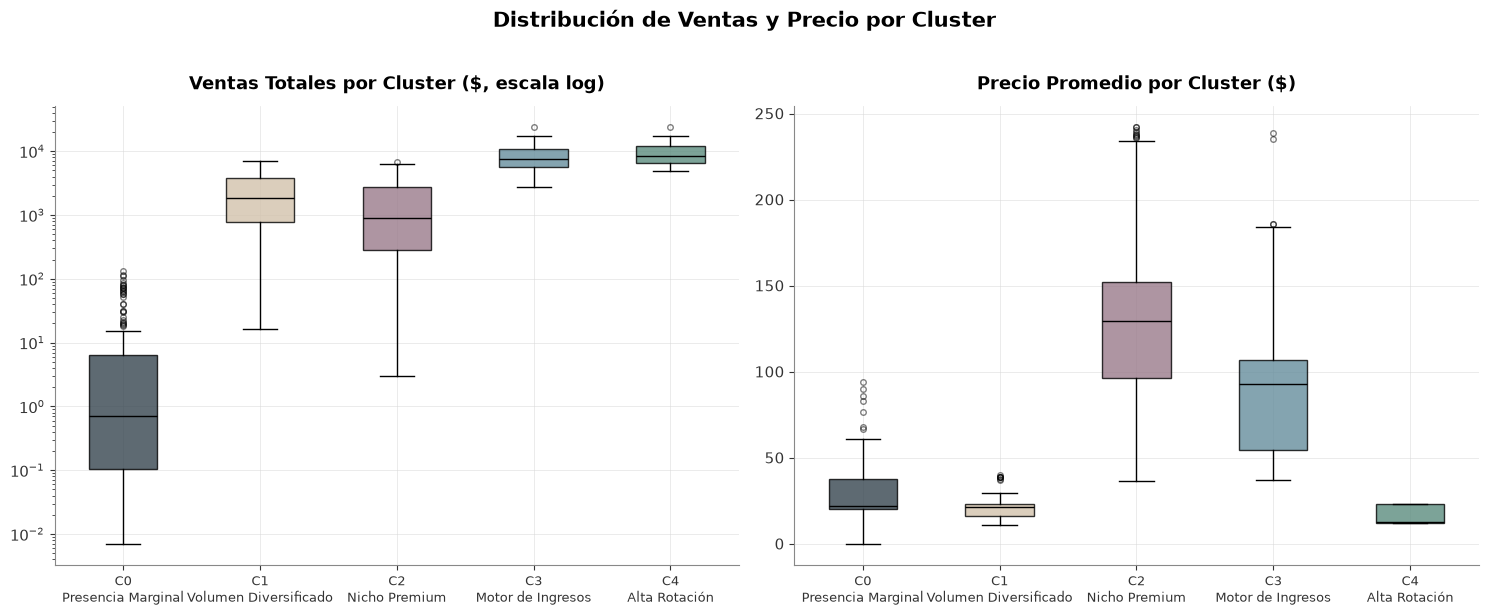

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Distribución de Ventas y Precio por Cluster', y=1.02)

cluster_order = sorted(df_agg['cluster'].unique())
cluster_data_sales = [df_agg[df_agg['cluster']==c]['sales_total'].values for c in cluster_order]
bp1 = axes[0].boxplot(cluster_data_sales, patch_artist=True, medianprops=dict(color='black'),
                       flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch, c in zip(bp1['boxes'], cluster_order):
    patch.set_facecolor(cluster_colores[c]); patch.set_alpha(0.8)
axes[0].set_yscale('log')
axes[0].set_xticklabels([f"C{c}\n{cluster_nombres[c]}" for c in cluster_order], fontsize=9)
axes[0].set_title('Ventas Totales por Cluster ($, escala log)')

cluster_data_price = [df_agg[df_agg['cluster']==c]['price_mean'].values for c in cluster_order]
bp2 = axes[1].boxplot(cluster_data_price, patch_artist=True, medianprops=dict(color='black'),
                       flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch, c in zip(bp2['boxes'], cluster_order):
    patch.set_facecolor(cluster_colores[c]); patch.set_alpha(0.8)
axes[1].set_xticklabels([f"C{c}\n{cluster_nombres[c]}" for c in cluster_order], fontsize=9)
axes[1].set_title('Precio Promedio por Cluster ($)')

plt.tight_layout()
plt.savefig('16_boxplot_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### Hallazgos

**Panel de Ventas Totales (izquierda, escala logarítmica):**
- La escala logarítmica es necesaria porque las magnitudes abarcan varios órdenes de magnitud: de centavos (Presencia Marginal) a miles de dólares por combinación (Motor de Ingresos, Alta Rotación).
- Motor de Ingresos y Alta Rotación tienen cajas en una posición muy similar. Aunque la de Alta Rotación es visiblemente más corta (menos dispersión interna), esto es coherente con agrupar menos combinaciones (22 frente a 57, según la tabla de perfiles de la sección 5.1) y ser, por lo tanto, un grupo más homogéneo.
- La caja de Presencia Marginal cae varios órdenes de magnitud por debajo del resto, consistente con ser el cluster de menor aportación económica.

**Panel de Precio Promedio (derecha):**
- Nicho Premium y Motor de Ingresos tienen cajas de altura casi idéntica, por lo que no se distinguen por qué tan dispersos son internamente, sino por su posición: Nicho Premium se ubica consistentemente más arriba (mediana ~$130 frente a ~$95).
- Alta Rotación y Volumen Diversificado tienen las cajas más cortas y bajas (mediana ~$15 y ~$20), consistente con productos de precio uniformemente bajo dentro de cada cluster.
- Alta Rotación es el único cluster sin ningún outlier, por lo que su precio queda completamente acotado (entre ~$15 y ~$25). En el otro extremo, Nicho Premium tiene outliers y el bigote superior más largo (hasta ~$235), seguido por Motor de Ingresos con menos outliers y bigote hasta ~$185, o sea que ambos tienen algunos productos bastante más caros que el resto de su propio cluster.

## 6.6 Vanish contra el mercado total

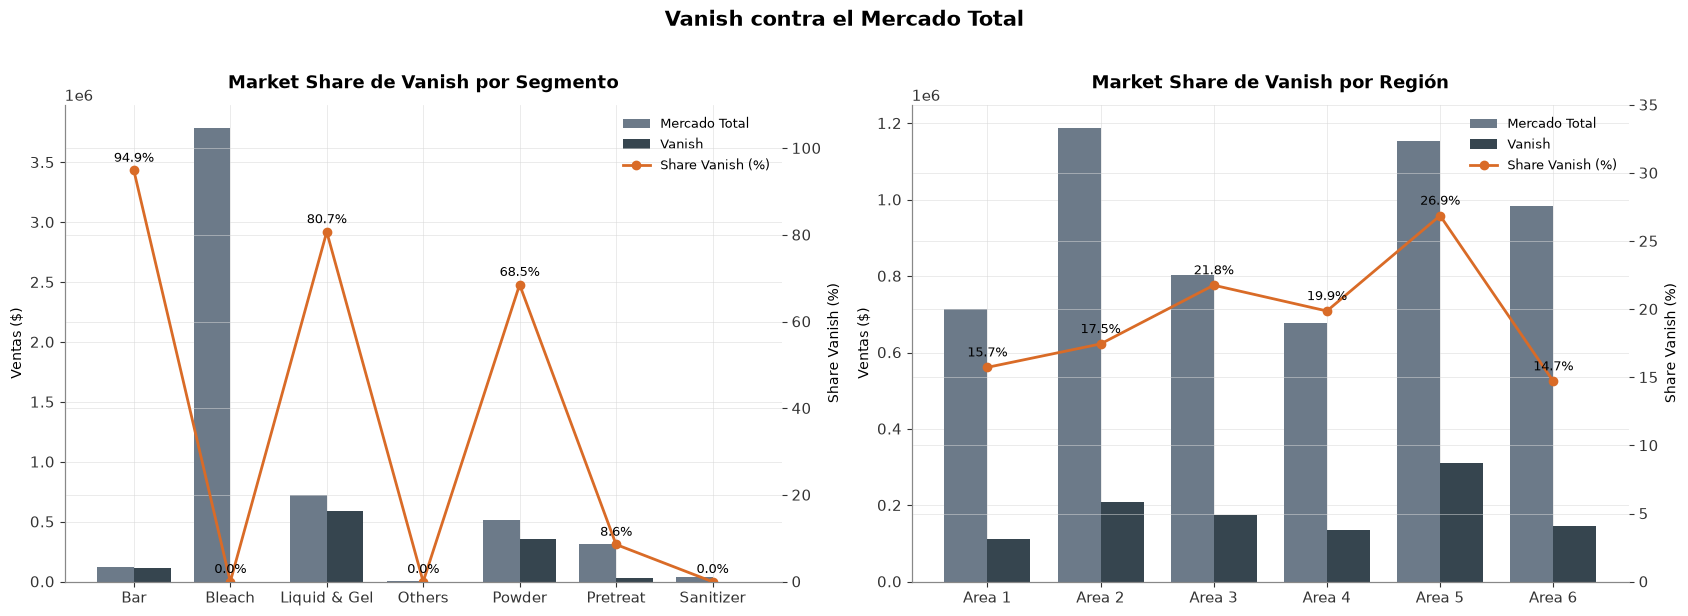

Market share de Vanish por segmento:
  Bar           mercado $  121,769.67  vanish $  115,527.86  share   94.9%
  Bleach        mercado $3,790,642.19  vanish $        0.00  share    0.0%
  Liquid & Gel  mercado $  727,028.13  vanish $  586,805.16  share   80.7%
  Others        mercado $    7,520.71  vanish $        0.00  share    0.0%
  Powder        mercado $  517,510.89  vanish $  354,688.96  share   68.5%
  Pretreat      mercado $  316,001.11  vanish $   27,122.88  share    8.6%
  Sanitizer     mercado $   40,957.87  vanish $        0.00  share    0.0%

Market share de Vanish por región:
  Area 1   mercado $  714,249.98  vanish $  112,386.93  share   15.7%
  Area 2   mercado $1,188,796.15  vanish $  207,487.35  share   17.5%
  Area 3   mercado $  803,655.34  vanish $  174,925.75  share   21.8%
  Area 4   mercado $  677,436.00  vanish $  134,621.68  share   19.9%
  Area 5   mercado $1,153,335.54  vanish $  309,934.98  share   26.9%
  Area 6   mercado $  983,957.57  vanish $  144,788.

In [41]:
ventas_seg_total = df.groupby('segment', observed=True)['total_value_sales'].sum()
ventas_seg_vanish = df_vanish.groupby('segment', observed=True)['total_value_sales'].sum()
share_seg = (ventas_seg_vanish / ventas_seg_total * 100).fillna(0)

ventas_reg_total = df.groupby('region_short')['total_value_sales'].sum()
ventas_reg_vanish = df_vanish.groupby('region_short')['total_value_sales'].sum()
share_reg = (ventas_reg_vanish / ventas_reg_total * 100).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
width = 0.38

ax1 = axes[0]
x = np.arange(len(ventas_seg_total.index))
ax1.bar(x - width/2, ventas_seg_total.values, width, label='Mercado Total', color=PALETTE['base'])
ax1.bar(x + width/2, ventas_seg_vanish.reindex(ventas_seg_total.index, fill_value=0).values, width, label='Vanish', color=PALETTE['primary'])
ax1b = ax1.twinx()
ax1b.plot(x, share_seg.reindex(ventas_seg_total.index, fill_value=0).values, marker='o', linewidth=2, color=PALETTE['accent'], label='Share Vanish (%)')
for i, val in enumerate(share_seg.reindex(ventas_seg_total.index, fill_value=0).values):
    ax1b.text(i, val + 2, f'{val:.1f}%', ha='center', fontsize=9)
ax1.set_title('Market Share de Vanish por Segmento')
ax1.set_xticks(x); ax1.set_xticklabels(ventas_seg_total.index)
ax1.set_ylabel('Ventas ($)'); ax1b.set_ylabel('Share Vanish (%)'); ax1b.set_ylim(0, 110)
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='upper right')

ax2 = axes[1]
x2 = np.arange(len(ventas_reg_total.index))
ax2.bar(x2 - width/2, ventas_reg_total.values, width, label='Mercado Total', color=PALETTE['base'])
ax2.bar(x2 + width/2, ventas_reg_vanish.reindex(ventas_reg_total.index, fill_value=0).values, width, label='Vanish', color=PALETTE['primary'])
ax2b = ax2.twinx()
ax2b.plot(x2, share_reg.reindex(ventas_reg_total.index, fill_value=0).values, marker='o', linewidth=2, color=PALETTE['accent'], label='Share Vanish (%)')
for i, val in enumerate(share_reg.reindex(ventas_reg_total.index, fill_value=0).values):
    ax2b.text(i, val + 0.8, f'{val:.1f}%', ha='center', fontsize=9)
ax2.set_title('Market Share de Vanish por Región')
ax2.set_xticks(x2); ax2.set_xticklabels(ventas_reg_total.index)
ax2.set_ylabel('Ventas ($)'); ax2b.set_ylabel('Share Vanish (%)'); ax2b.set_ylim(0, 35)
l1, lb1 = ax2.get_legend_handles_labels(); l2, lb2 = ax2b.get_legend_handles_labels()
ax2.legend(l1+l2, lb1+lb2, loc='upper right')

fig.suptitle('Vanish contra el Mercado Total', y=1.02)
plt.tight_layout()
plt.savefig('17_vanish_market_share.png', dpi=150, bbox_inches='tight')
plt.show()

print("Market share de Vanish por segmento:")
for seg in ventas_seg_total.index:
    total = ventas_seg_total.get(seg, 0); vanish = ventas_seg_vanish.get(seg, 0)
    share = (vanish/total*100) if total > 0 else 0
    print(f"  {seg:<13} mercado ${total:>12,.2f}  vanish ${vanish:>12,.2f}  share {share:>6.1f}%")
print("\nMarket share de Vanish por región:")
for reg in ventas_reg_total.index:
    total = ventas_reg_total.get(reg, 0); vanish = ventas_reg_vanish.get(reg, 0)
    share = (vanish/total*100) if total > 0 else 0
    print(f"  {reg:<8} mercado ${total:>12,.2f}  vanish ${vanish:>12,.2f}  share {share:>6.1f}%")

### Hallazgos

- Vanish domina tres de los cuatro segmentos donde tiene presencia: Bar (94.9%), Liquid & Gel (80.7%) y Powder (68.5%). En el cuarto, Pretreat, su presencia es débil con apenas $27,123 de venta sobre un mercado de $316,001 (8.6% de share), este es el segmento con más terreno por ganar.
- Vanish no tiene ningún registro en los otros tres segmentos del mercado (Bleach, Sanitizer, Others): son mercados adyacentes sin ninguna presencia de la marca.
- Por región, la participación de Vanish es más pareja que por segmento: va de 14.7% (Área 6) a 26.9% (Área 5), un rango de menos de 2x. Ningún área concentra de forma desproporcionada el desempeño de la marca.

## 6.7 Clusters contra market share: qué cluster explica cada posición competitiva

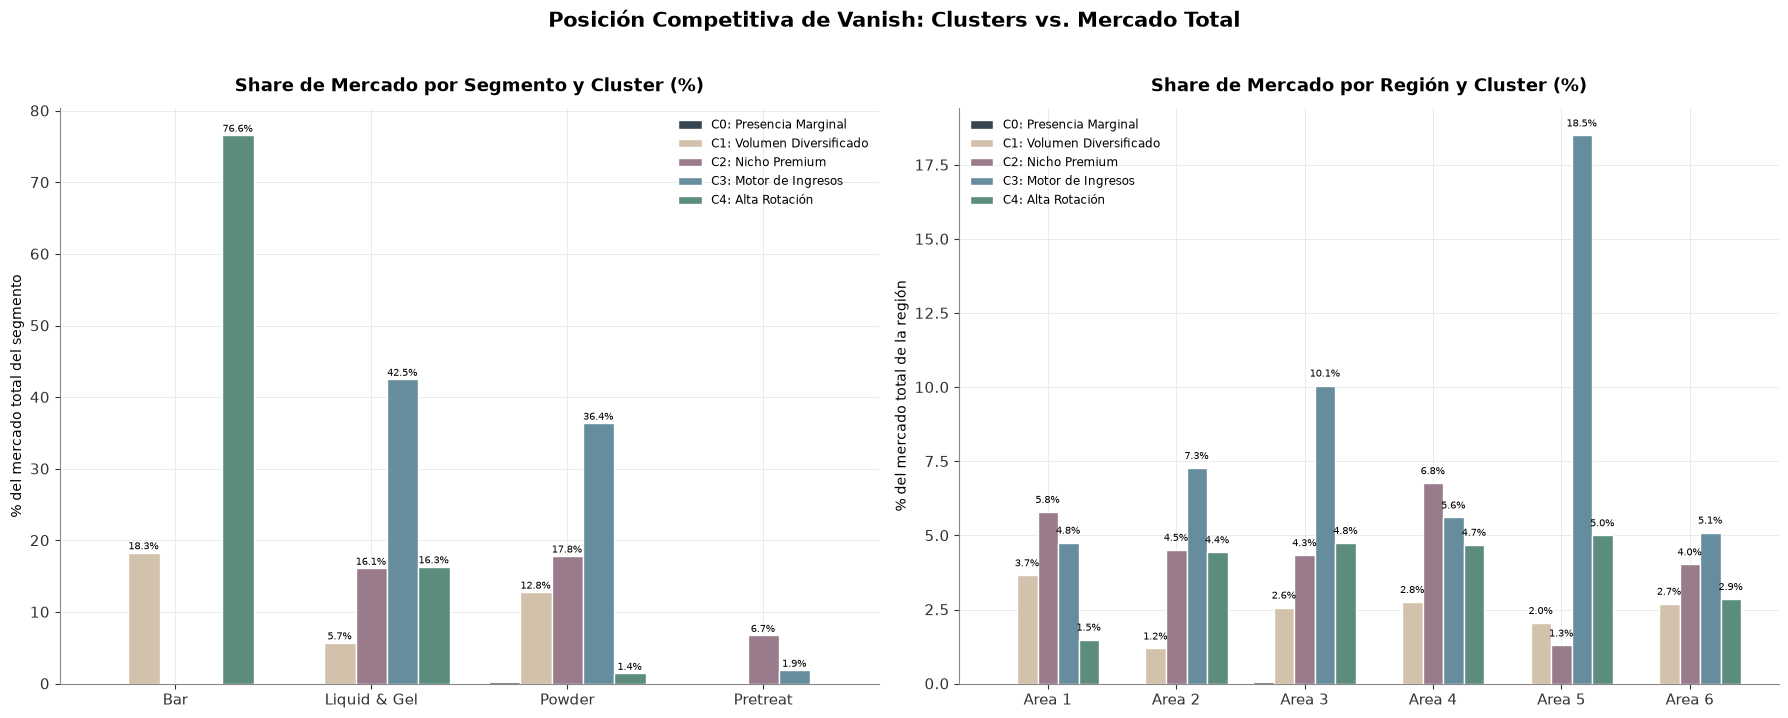

Share de mercado de Vanish por cluster y segmento:
 cluster        cluster_nombre      segment  ventas_vanish_cluster  ventas_mercado_seg  share_pct
       0    Presencia Marginal       Powder                869.506          517510.888       0.17
       0    Presencia Marginal Liquid & Gel                822.178          727028.128       0.11
       0    Presencia Marginal          Bar                 50.163          121769.670       0.04
       1 Volumen Diversificado       Powder              66093.222          517510.888      12.77
       1 Volumen Diversificado Liquid & Gel              41397.912          727028.128       5.69
       1 Volumen Diversificado          Bar              22242.842          121769.670      18.27
       2         Nicho Premium Liquid & Gel             117040.091          727028.128      16.10
       2         Nicho Premium       Powder              92149.018          517510.888      17.81
       2         Nicho Premium     Pretreat              21253.979 

In [42]:
vanish_seg_cluster = df_agg.groupby(['cluster', 'cluster_nombre', 'segment'])['sales_total'].sum().reset_index()
vanish_seg_cluster.columns = ['cluster', 'cluster_nombre', 'segment', 'ventas_vanish_cluster']
vanish_seg_cluster['ventas_mercado_seg'] = vanish_seg_cluster['segment'].map(ventas_seg_total)
vanish_seg_cluster['share_pct'] = (vanish_seg_cluster['ventas_vanish_cluster'] / vanish_seg_cluster['ventas_mercado_seg'] * 100).round(2)

vanish_reg_cluster = df_agg.groupby(['cluster', 'cluster_nombre', 'region'])['sales_total'].sum().reset_index()
vanish_reg_cluster.columns = ['cluster', 'cluster_nombre', 'region', 'ventas_vanish_cluster']
vanish_reg_cluster['ventas_mercado_reg'] = vanish_reg_cluster['region'].map(ventas_reg_total)
vanish_reg_cluster['share_pct'] = (vanish_reg_cluster['ventas_vanish_cluster'] / vanish_reg_cluster['ventas_mercado_reg'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Posición Competitiva de Vanish: Clusters vs. Mercado Total', y=1.02)
bar_width = 0.16

ax = axes[0]
segmentos_vanish = sorted(vanish_seg_cluster['segment'].unique())
x = np.arange(len(segmentos_vanish))
clusters_ordenados = sorted(vanish_seg_cluster['cluster'].unique())
offsets = np.linspace(-(len(clusters_ordenados)-1)/2, (len(clusters_ordenados)-1)/2, len(clusters_ordenados)) * bar_width
for idx, c in enumerate(clusters_ordenados):
    sub = vanish_seg_cluster[vanish_seg_cluster['cluster']==c].set_index('segment')
    valores = [sub.loc[seg, 'share_pct'] if seg in sub.index else 0 for seg in segmentos_vanish]
    bars = ax.bar(x + offsets[idx], valores, width=bar_width, color=cluster_colores[c], edgecolor='white', label=f"C{c}: {cluster_nombres[c]}")
    for bar, v in zip(bars, valores):
        if v > 0.5:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{v:.1f}%', ha='center', fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(segmentos_vanish)
ax.set_title('Share de Mercado por Segmento y Cluster (%)')
ax.set_ylabel('% del mercado total del segmento')
ax.legend(fontsize=8.5, loc='upper right')

ax2 = axes[1]
regiones_vanish = sorted(vanish_reg_cluster['region'].unique())
x2 = np.arange(len(regiones_vanish))
for idx, c in enumerate(clusters_ordenados):
    sub = vanish_reg_cluster[vanish_reg_cluster['cluster']==c].set_index('region')
    valores = [sub.loc[reg, 'share_pct'] if reg in sub.index else 0 for reg in regiones_vanish]
    bars = ax2.bar(x2 + offsets[idx], valores, width=bar_width, color=cluster_colores[c], edgecolor='white', label=f"C{c}: {cluster_nombres[c]}")
    for bar, v in zip(bars, valores):
        if v > 0.5:
            ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{v:.1f}%', ha='center', fontsize=7.5)
ax2.set_xticks(x2); ax2.set_xticklabels(regiones_vanish)
ax2.set_title('Share de Mercado por Región y Cluster (%)')
ax2.set_ylabel('% del mercado total de la región')
ax2.legend(fontsize=8.5, loc='best')

plt.tight_layout()
plt.savefig('18_clusters_market_share.png', dpi=150, bbox_inches='tight')
plt.show()

print("Share de mercado de Vanish por cluster y segmento:")
print(vanish_seg_cluster.sort_values(['cluster','ventas_vanish_cluster'], ascending=[True,False]).to_string(index=False))

### Hallazgos

- El dominio de Vanish en Bar (94.9% del mercado) se explica casi por completo por dos clusters muy distintos entre sí: Alta Rotación aporta 76.6 puntos porcentuales con solo 22 combinaciones producto-región, y Volumen Diversificado aporta otros 18.3 puntos con una base algo más amplia (54 combinaciones). Son dos estrategias de éxito diferentes dentro del mismo segmento.
- Motor de Ingresos es el principal responsable del liderazgo de Vanish en Liquid & Gel (42.5 de los 80.7 puntos de share) y en Powder (36.4 de los 68.5 puntos), es el cluster que más pesa en los dos segmentos de mayor tamaño para la marca.
- En Pretreat, el segmento más débil de Vanish, solo dos clusters tienen alguna presencia: NichoPremium (6.7% de share) y Motor de Ingresos, a mucha distancia (1.9%). Cualquier estrategia de crecimiento en esa categoría depende casi por completo de Nicho Premium.
- Geográficamente, Motor de Ingresos y Nicho Premium muestran patrones casi opuestos: donde uno es más fuerte, el otro es más débil. Motor de Ingresos alcanza su mejor share en Área 5 (18.5%) pero ahí Nicho Premium cae a su mínimo (1.3%); Nicho Premium es relativamente más fuerte en Área 4 (6.8%), donde Motor de Ingresos es más moderado (5.6%).

# 7. Interpretar y analizar los clusters

## 7.1 Resumen de resultados

In [43]:
for c in range(k_optimo):
    mask = df_agg['cluster'] == c
    df_c = df_agg[mask]
    ventas_total_c = df_c['sales_total'].sum()
    ventas_pct = ventas_total_c / df_agg['sales_total'].sum() * 100

    print(f"\n{'='*60}")
    print(f"Cluster {c}: {cluster_nombres[c].upper()}")
    print(f"{'='*60}")
    print(f"Registros        → {mask.sum()} ({mask.sum()/len(df_agg)*100:.1f}%)")
    print(f"Ventas totales   → ${ventas_total_c:,.2f} ({ventas_pct:.1f}% del total Vanish)")
    print(f"Precio medio     → ${df_c['price_mean'].mean():.2f}")
    print(f"Rotación media   → {df_c['units_mean'].mean():.2f} uds/semana")
    print(f"\nDistribución por segmento:")
    for seg, cnt in df_c['segment'].value_counts().items():
        print(f"    {seg:<13}→ {cnt:>3} ({cnt/mask.sum()*100:.1f}%)")
    print(f"\nDistribución por región:")
    for reg, cnt in df_c['region'].value_counts().items():
        print(f"    {reg:<13}→ {cnt:>3} ({cnt/mask.sum()*100:.1f}%)")


Cluster 0: PRESENCIA MARGINAL
Registros        → 129 (32.1%)
Ventas totales   → $1,741.85 (0.2% del total Vanish)
Precio medio     → $30.18
Rotación media   → 0.01 uds/semana

Distribución por segmento:
    Powder       →  61 (47.3%)
    Liquid & Gel →  51 (39.5%)
    Bar          →  17 (13.2%)

Distribución por región:
    Area 1       →  26 (20.2%)
    Area 2       →  22 (17.1%)
    Area 6       →  22 (17.1%)
    Area 4       →  21 (16.3%)
    Area 3       →  20 (15.5%)
    Area 5       →  18 (14.0%)

Cluster 1: VOLUMEN DIVERSIFICADO
Registros        → 54 (13.4%)
Ventas totales   → $129,733.98 (12.0% del total Vanish)
Precio medio     → $21.37
Rotación media   → 1.53 uds/semana

Distribución por segmento:
    Liquid & Gel →  22 (40.7%)
    Powder       →  19 (35.2%)
    Bar          →  13 (24.1%)

Distribución por región:
    Area 6       →  10 (18.5%)
    Area 1       →  10 (18.5%)
    Area 2       →   9 (16.7%)
    Area 4       →   9 (16.7%)
    Area 3       →   8 (14.8%)
    Area

## 7.2 Documentar los insights obtenidos

In [44]:
insights_ejecutivos = f'''
-----------------------------------------------------------------
CONTEXTO
-----------------------------------------------------------------

Algoritmo     : K-Means con k=5 clusters, optimizado con k-means++ y 50 inicializaciones
Datos         : {len(df_vanish):,} registros de Vanish sobre un total de {len(df):,} en el mercado
Participación : {df_vanish["total_value_sales"].sum()/df["total_value_sales"].sum()*100:.1f}% de las ventas totales del portafolio
Validación    : Silhouette={sil_final:.3f} | Davies-Bouldin={db_final:.3f} | Calinski-Harabasz={ch_final:.1f}

-----------------------------------------------------------------
LOS CINCO CLUSTERS: FORTALEZAS Y AREAS DE MEJORA
-----------------------------------------------------------------

Cluster 3: MOTOR DE INGRESOS (46.4% de las ventas de Vanish)
  - {(df_agg["cluster"]==3).sum()} combinaciones producto-región, precio alto (${metricas_cluster.loc[3,"precio_medio"]:.2f}) y rotación real sólida
  - Motor del liderazgo de Vanish en Liquid & Gel (42.5% de share) y Powder (36.4% de share)
  - Su mejor mercado es Área 5 (18.5% de share); en el resto de áreas su share cae a 4.8-10.1%
  → Entender qué hace exitosa la ejecución en Área 5 y evaluar si es replicable en otras áreas

Cluster 2: NICHO PREMIUM (21.3% de las ventas de Vanish)
  - {(df_agg["cluster"]==2).sum()} combinaciones, el precio más alto del portafolio (${metricas_cluster.loc[2,"precio_medio"]:.2f}), rotación mínima
  - Uno de los dos únicos clusters con presencia en Pretreat (6.7% de share), muy por delante de Motor de Ingresos (1.9%), el segmento más débil de la marca
  - Su mejor desempeño relativo está en Área 4; su mínimo es Área 5, justo donde C3 es más fuerte
  → Explorar si hay una relación de sustitución entre C3 y C2 por región antes de decidir dónde invertir

Cluster 4: ALTA ROTACION (20.2% de las ventas de Vanish)
  - Solo {metricas_cluster.loc[4,"productos_unicos"]:.0f} productos únicos en {(df_agg["cluster"]==4).sum()} combinaciones, pero con 76.6% de share en Bar
  - Rotación real de {metricas_cluster.loc[4,"rotacion_sem_media"]:.2f} uds/semana, la más alta de todo el portafolio, a precio mínimo
  - Presente en las seis áreas, con share de 1.5% a 5.0%
  → Proteger el abasto de estos SKUs: son pocos productos con un impacto desproporcionado en Bar

Cluster 1: VOLUMEN DIVERSIFICADO (12.0% de las ventas de Vanish)
  - {(df_agg["cluster"]==1).sum()} combinaciones, precio bajo (${metricas_cluster.loc[1,"precio_medio"]:.2f}) y rotación real alta ({metricas_cluster.loc[1,"rotacion_sem_media"]:.2f} uds/semana)
  - Aporta 18.3% de share en Bar, la base más amplia detrás del liderazgo de Vanish en ese segmento
  - Presente en las seis áreas, más fuerte en Área 1 y Área 4 (3.7% y 2.8% de share)
  → Es la base de volumen del segmento Bar; mantener presencia constante en anaquel

Cluster 0: PRESENCIA MARGINAL (0.2% de las ventas de Vanish)
  - {(df_agg["cluster"]==0).sum()} combinaciones (el grupo más grande en número), apenas ${metricas_cluster.loc[0,"ventas_totales"]:,.0f} en ventas
  - Presencia temporal de solo {metricas_cluster.loc[0,"semanas_promedio"]:.0f} semanas en promedio, menos de un tercio del resto de clusters
  - Distribuido de forma pareja en las seis áreas: no es un problema regional, es transversal
  -> Auditar por SKU: decidir entre reforzar distribución o descontinuar

-----------------------------------------------------------------
PATRONES TRANSVERSALES
-----------------------------------------------------------------

1. El liderazgo de Vanish en Bar (94.9%) descansa en dos clusters de perfil opuesto: Alta Rotación (pocos SKUs, impacto desproporcionado) 
   y Volumen Diversificado (base algo más amplia). Son dos rutas distintas hacia el mismo resultado competitivo.

2. Motor de Ingresos y Nicho Premium muestran un patrón geográfico casi inverso entre sí: donde uno es fuerte, el otro tiende a ser débil, 
   particularmente entre Área 5 y Área 4. Vale la pena investigar si esto refleja una decisión de mezcla de portafolio por región o una oportunidad 
   de distribución sin explotar.

3. Presencia Marginal no es un problema de ninguna región en particular, aparece de forma pareja en las seis áreas, lo que sugiere que la causa es
   a nivel de producto (SKU) más que de ejecución geográfica.

-----------------------------------------------------------------
RECOMENDACIONES
-----------------------------------------------------------------

Prioridad ALTA  → Auditar Presencia Marginal por SKU: retener o descontinuar
Prioridad ALTA  → Investigar el patrón inverso Motor de Ingresos / Nicho Premium por región
Prioridad MEDIA → Proteger el abasto de los SKUs de Alta Rotación (impacto desproporcionado en Bar)
Prioridad MEDIA → Explorar crecimiento en Pretreat: Nicho Premium tiene casi toda la tracción del segmento (6.7% vs. 1.9% de Motor de Ingresos)
'''

print(insights_ejecutivos)

with open('insights_clustering_vanish.txt', 'w', encoding='utf-8') as f:
    f.write(insights_ejecutivos)


-----------------------------------------------------------------
CONTEXTO
-----------------------------------------------------------------

Algoritmo     : K-Means con k=5 clusters, optimizado con k-means++ y 50 inicializaciones
Datos         : 23,626 registros de Vanish sobre un total de 101,012 en el mercado
Participación : 19.6% de las ventas totales del portafolio
Validación    : Silhouette=0.412 | Davies-Bouldin=0.911 | Calinski-Harabasz=261.2

-----------------------------------------------------------------
LOS CINCO CLUSTERS: FORTALEZAS Y AREAS DE MEJORA
-----------------------------------------------------------------

Cluster 3: MOTOR DE INGRESOS (46.4% de las ventas de Vanish)
  - 57 combinaciones producto-región, precio alto ($95.64) y rotación real sólida
  - Motor del liderazgo de Vanish en Liquid & Gel (42.5% de share) y Powder (36.4% de share)
  - Su mejor mercado es Área 5 (18.5% de share); en el resto de áreas su share cae a 4.8-10.1%
  → Entender qué hace exitosa 

# 8. Guardar los resultados y el modelo

In [45]:
import os

cols_export = ['item_code', 'region', 'segment', 'format', 'sales_total', 'sales_mean', 'units_total',
               'units_mean', 'price_mean', 'var_pct_mean', 'high_value_ratio',
               'high_turnover_ratio', 'n_weeks', 'cluster', 'cluster_nombre']
df_resultados = df_agg[cols_export].copy()
df_resultados.to_csv('clustering_resultados_vanish.csv', index=False, encoding='utf-8-sig')
print(f"Archivo 1: clustering_resultados_vanish.csv ({len(df_resultados):,} filas)")

df_resumen = df_agg.groupby(['cluster', 'cluster_nombre']).agg(
    n_registros=('item_code', 'count'), ventas_totales=('sales_total', 'sum'),
    ventas_promedio=('sales_total', 'mean'), precio_promedio=('price_mean', 'mean'),
    unidades_totales=('units_total', 'sum'), rotacion_semanal=('units_mean', 'mean'),
    pct_alto_valor=('high_value_ratio', 'mean'), pct_alta_rotacion=('high_turnover_ratio', 'mean'),
    semanas_promedio=('n_weeks', 'mean')
).round(3).reset_index()
df_resumen['pct_ventas_total'] = (df_resumen['ventas_totales'] / df_resumen['ventas_totales'].sum() * 100).round(2)
df_resumen.to_csv('clustering_resumen_por_cluster.csv', index=False, encoding='utf-8-sig')
print(f"Archivo 2: clustering_resumen_por_cluster.csv ({len(df_resumen)} filas)")

df_comp = df_agg.groupby(['cluster', 'cluster_nombre', 'segment']).agg(
    n_registros=('item_code', 'count'), ventas_totales=('sales_total', 'sum'),
    precio_medio=('price_mean', 'mean'), rotacion_media=('units_mean', 'mean')
).round(3).reset_index()
df_comp.to_csv('clustering_composicion_segmento.csv', index=False, encoding='utf-8-sig')
print(f"Archivo 3: clustering_composicion_segmento.csv ({len(df_comp)} filas)")

df_geo = df_agg.groupby(['cluster', 'cluster_nombre', 'region']).agg(
    n_registros=('item_code', 'count'), ventas_totales=('sales_total', 'sum'), precio_medio=('price_mean', 'mean')
).round(3).reset_index()
df_geo.to_csv('clustering_distribucion_geografica.csv', index=False, encoding='utf-8-sig')
print(f"Archivo 4: clustering_distribucion_geografica.csv ({len(df_geo)} filas)")

df_mks_seg = vanish_seg_cluster[['cluster', 'cluster_nombre', 'segment', 'ventas_vanish_cluster', 'ventas_mercado_seg', 'share_pct']].copy()
df_mks_seg.to_csv('clustering_market_share_segmento.csv', index=False, encoding='utf-8-sig')
print(f"Archivo 5: clustering_market_share_segmento.csv ({len(df_mks_seg)} filas)")

df_mks_reg = vanish_reg_cluster[['cluster', 'cluster_nombre', 'region', 'ventas_vanish_cluster', 'ventas_mercado_reg', 'share_pct']].copy()
df_mks_reg.to_csv('clustering_market_share_region.csv', index=False, encoding='utf-8-sig')
print(f"Archivo 6: clustering_market_share_region.csv ({len(df_mks_reg)} filas)")

archivos = [
    ('11_metodo_codo.png', 'Codo + 3 métricas de validación'),
    ('12_scatter_pca_clusters.png', 'Dispersión PCA 2D'),
    ('13_ventas_por_cluster.png', 'Ventas, precio, rotación y número de registros por cluster'),
    ('14_heatmap_perfiles.png', 'Heatmap de centroides'),
    ('15_composicion_clusters.png', 'Composición por segmento y región'),
    ('16_boxplot_clusters.png', 'Boxplot de ventas y precio'),
    ('17_vanish_market_share.png', 'Share de Vanish del mercado total'),
    ('18_clusters_market_share.png', 'Share de mercado por cluster'),
    ('clustering_resultados_vanish.csv', 'Registros con cluster asignado'),
    ('clustering_resumen_por_cluster.csv', 'KPIs por cluster'),
    ('clustering_composicion_segmento.csv', 'Distribución por segmento'),
    ('clustering_distribucion_geografica.csv', 'Distribución por región'),
    ('clustering_market_share_segmento.csv', 'Clusters cruzados con market share por segmento'),
    ('clustering_market_share_region.csv', 'Clusters cruzados con market share por región'),
    ('insights_clustering_vanish.txt', 'Insights y recomendaciones'),
]
print(f"\n{'#':>3}  {'Archivo':<42} Descripción")
for i, (archivo, desc) in enumerate(archivos, 1):
    existe = 'ok' if os.path.exists(archivo) else '--'
    print(f"{i:>3}  {archivo:<42} [{existe}] {desc}")
print(f"\nTotal: {len(archivos)} archivos")

Archivo 1: clustering_resultados_vanish.csv (402 filas)
Archivo 2: clustering_resumen_por_cluster.csv (5 filas)
Archivo 3: clustering_composicion_segmento.csv (15 filas)
Archivo 4: clustering_distribucion_geografica.csv (30 filas)
Archivo 5: clustering_market_share_segmento.csv (15 filas)
Archivo 6: clustering_market_share_region.csv (30 filas)

  #  Archivo                                    Descripción
  1  11_metodo_codo.png                         [ok] Codo + 3 métricas de validación
  2  12_scatter_pca_clusters.png                [ok] Dispersión PCA 2D
  3  13_ventas_por_cluster.png                  [ok] Ventas, precio, rotación y número de registros por cluster
  4  14_heatmap_perfiles.png                    [ok] Heatmap de centroides
  5  15_composicion_clusters.png                [ok] Composición por segmento y región
  6  16_boxplot_clusters.png                    [ok] Boxplot de ventas y precio
  7  17_vanish_market_share.png                 [ok] Share de Vanish del mercado t

## Conclusiones

**El portafolio de Vanish no es un bloque homogéneo: son cinco negocios distintos conviviendo bajo la misma marca:**

  Van desde un núcleo de alto valor (Motor de Ingresos) que por sí solo genera casi la mitad del ingreso, hasta un grupo de presencia marginal que ocupa un tercio de los registros pero apenas un 0.2% de las ventas. Esa amplitud es, en sí misma, el hallazgo central: tratar a Vanish como una sola unidad de negocio ocultaría decisiones muy distintas que cada segmento necesita.

**El liderazgo de Vanish en Bar (94.9% de share) se sostiene sobre dos estrategias opuestas que conviven en paralelo:**

  Pocas SKUs de rotación extrema con un impacto desproporcionado, y una base algo más amplia de productos de rotación alta pero menos extrema. Ninguna de las dos explica el liderazgo por sí sola, ambas son necesarias.

**La relación geográfica inversa entre Motor de Ingresos y Nicho Premium:**

  Fuertes en regiones opuestas es un hallazgo intrigante del análisis y amerita seguimiento: podría reflejar una estrategia de mezcla de portafolio deliberada por región, o una oportunidad de distribución cruzada sin explotar. Cualquiera de las dos explicaciones tiene implicaciones directas de negocio.

**Limitaciones a tener en cuenta:**

  El modelo se entrenó sobre 402 combinaciones producto-región de Vanish, un tamaño de muestra razonable pero no grande, especialmente para Alta Rotación, que descansa en solo 5 productos únicos. Sus conclusiones son robustas dentro del periodo analizado, pero deben revalidarse si el catálogo de productos cambia. La rotación se mide con `units_mean` (promedio real de unidades vendidas por semana) en vez de la columna de rotación histórica de la fuente, que ya viene como un promedio móvil calibrado a una escala distinta (documentado en la sección 2.2).

**Próximos pasos:**

  Este análisis de clustering completa esta línea de tres proyectos del portafolio (ETL, EDA y Clustering) construida sobre el mismo dataset de ventas retail, aplicando en cada etapa el mismo estándar de rigor: validar los datos antes de confiar en ellos, y validar los resultados del modelo antes de convertirlos en recomendaciones de negocio.